In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
# phi_agg_dfs = []

# for face in dp.boulder_agg_data.select("tile_face").unique().collect()["tile_face"]:
#     phis = dp.Phi_mesh.filter(pl.col("face") == face).collect()
#     mac = dp.mask_atlas_combined.filter(pl.col("face") == face).collect()

#     joint = mac.join(phis, on = ["face", "i", "j"], how="inner").select(
#         ["face", "i", "j", "row_id", "area"]
#     ).group_by(["row_id"]).agg(
#         pl.col("area").sum()
#     )

#     phi_agg_dfs.append(joint)

# phi_agg_df = pl.concat(phi_agg_dfs)

# phi_agg_df.write_parquet("phi_agg_df.parquet")
phi_agg_df = pl.read_parquet("phi_agg_df.parquet").with_columns(
    (pl.col("area") * 1e6).alias("area_m_sqr")
)

phi_agg_df

row_id,area,area_m_sqr
u32,f32,f32
1452761,5.9158e-7,0.591575
751089,5.0752e-8,0.050752
813368,9.2610e-8,0.09261
727509,0.000012,12.134059
3396152,6.5128e-8,0.065128
…,…,…
3234122,1.4833e-7,0.148327
1872984,5.3261e-9,0.005326
1823451,1.3778e-7,0.137779


In [16]:
gamma_df = dp.boulder_agg_data.collect().join(phi_agg_df, on="row_id", how="inner").with_columns(
    (1e3 * pl.col("longest_axis_diameter")).alias("longest_axis_diameter_m")
).with_columns(
    (np.pi * (pl.col("longest_axis_diameter_m") / 2) ** 2).alias("LAD_based_area")
).with_columns(
    (pl.col("area_m_sqr") / pl.col("LAD_based_area")).alias("g"),
    (pl.col("area_m_sqr") / pl.col("alpha")).alias("Phi"),
).filter(pl.col("g") > 0, pl.col("g") < 3) # Remove unrealistic values

gamma_df

row_id,tile_face,tile_lod_number,tile_lod_code,longest_axis_diameter,surface_area,mean_i,mean_j,max_i,max_j,min_i,min_j,mean_position_x,mean_position_y,mean_position_z,alpha,lod_level,lod_code,area,area_m_sqr,longest_axis_diameter_m,LAD_based_area,g,Phi
u32,str,i64,str,f32,f32,f64,f64,u32,u32,u32,u32,f32,f32,f32,u32,u8,str,f32,f32,f32,f32,f32,f64
1452761,"""posx""",4,"""BCAA""",0.001098,0.000001,2313.839623,4279.853774,2321,4289,2306,4271,0.010061,-0.22303,-0.09704,212,4,"""BCAA""",5.9158e-7,0.591575,1.098352,0.947486,0.624363,0.00279
751089,"""posx""",4,"""ADAA""",0.000224,6.8698e-8,2207.1,2540.95,2209,2543,2205,2539,-0.079473,-0.209466,-0.096595,20,4,"""ADAA""",5.0752e-8,0.050752,0.223792,0.039335,1.290252,0.002538
813368,"""posx""",4,"""ADBB""",0.000381,1.4329e-7,2252.65625,3872.875,2256,3875,2249,3870,-0.012216,-0.225185,-0.101341,32,4,"""ADBB""",9.2610e-8,0.09261,0.380666,0.11381,0.81373,0.002894
727509,"""posx""",2,"""AD""",0.005042,0.000025,3224.5,3830.1,3255,3863,3192,3788,-0.016015,-0.247557,-0.052666,3200,2,"""AD""",0.000012,12.134059,5.041579,19.962872,0.607831,0.003792
3396152,"""posx""",4,"""DBDC""",0.000338,9.8776e-8,5691.973684,7252.894737,5694,7257,5690,7249,0.148804,-0.192997,0.075203,38,4,"""DBDC""",6.5128e-8,0.065128,0.33815,0.089807,0.725201,0.001714
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3234122,"""posy""",4,"""DBAD""",0.00047,2.5669e-7,5110.784091,7076.261364,5115,7081,5106,7071,0.045918,-0.134764,0.185155,88,4,"""DBAD""",1.4833e-7,0.148327,0.469561,0.173171,0.856535,0.001686
1872984,"""posy""",3,"""BDD""",0.000053,2.5576e-9,3610.5,7818.5,3611,7819,3610,7818,-0.020516,-0.157621,0.173377,4,3,"""BDD""",5.3261e-9,0.005326,0.052883,0.002196,2.424901,0.001332
1823451,"""posy""",4,"""BDCA""",0.000499,2.3965e-7,3310.704225,6549.084507,3314,6555,3307,6543,-0.037444,-0.117105,0.195447,71,4,"""BDCA""",1.3778e-7,0.137779,0.498727,0.195351,0.705292,0.001941


mu: 0.6596
sigma: 0.1529


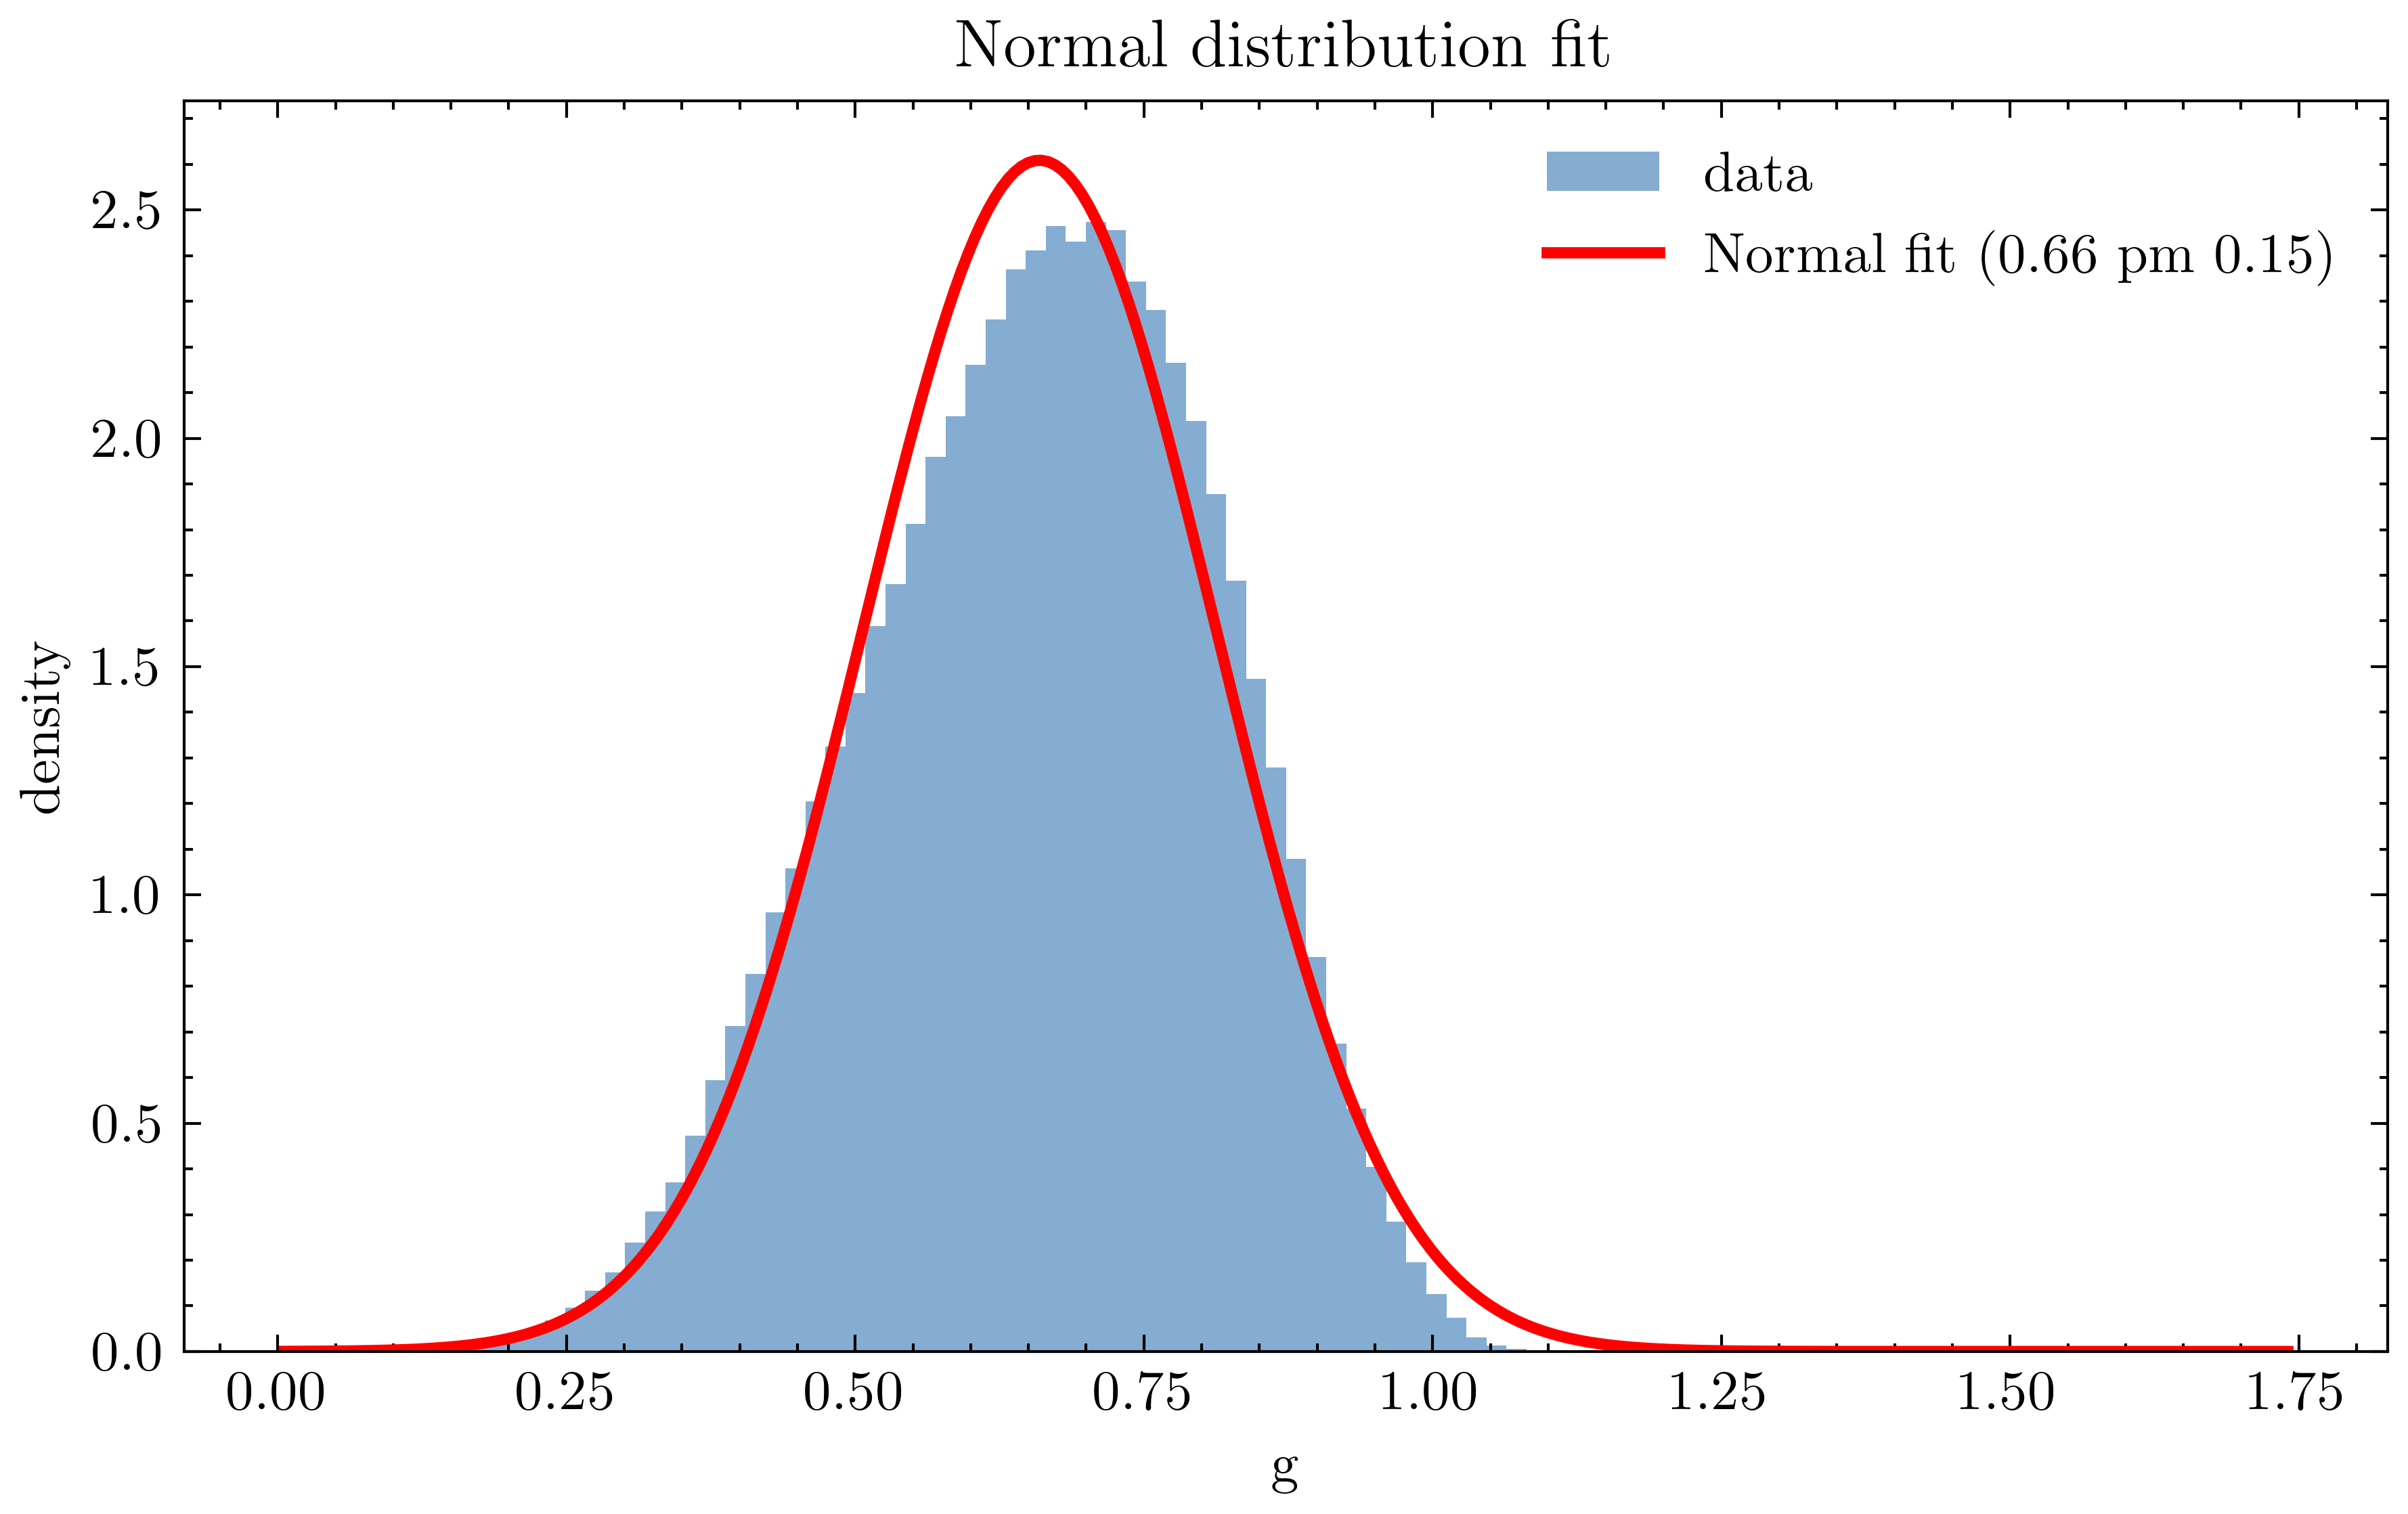

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from scipy.stats import norm

# --- data ---
gs = gamma_df.filter(
    (pl.col("alpha") > 21),
    (pl.col("longest_axis_diameter_m") > 0.5)
)["g"].to_numpy()

# --- fit normal distribution ---
mu, sigma = norm.fit(gs)

print(f"mu: {mu:.4f}")
print(f"sigma: {sigma:.4f}")

# --- plot ---
x = np.linspace(gs.min(), gs.max(), 300)
pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(7, 4))
plt.hist(gs, bins=100, density=True, alpha=0.5, label="data")
plt.plot(x, pdf, 'r', lw=2, label=f"Normal fit ({mu:.2f} pm {sigma:.2f})")

plt.xlabel("g")
plt.ylabel("density")
plt.title("Normal distribution fit")
plt.legend()
plt.show()

C:\Users\Joshu\AppData\Local\Temp\ipykernel_14564\2838766178.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


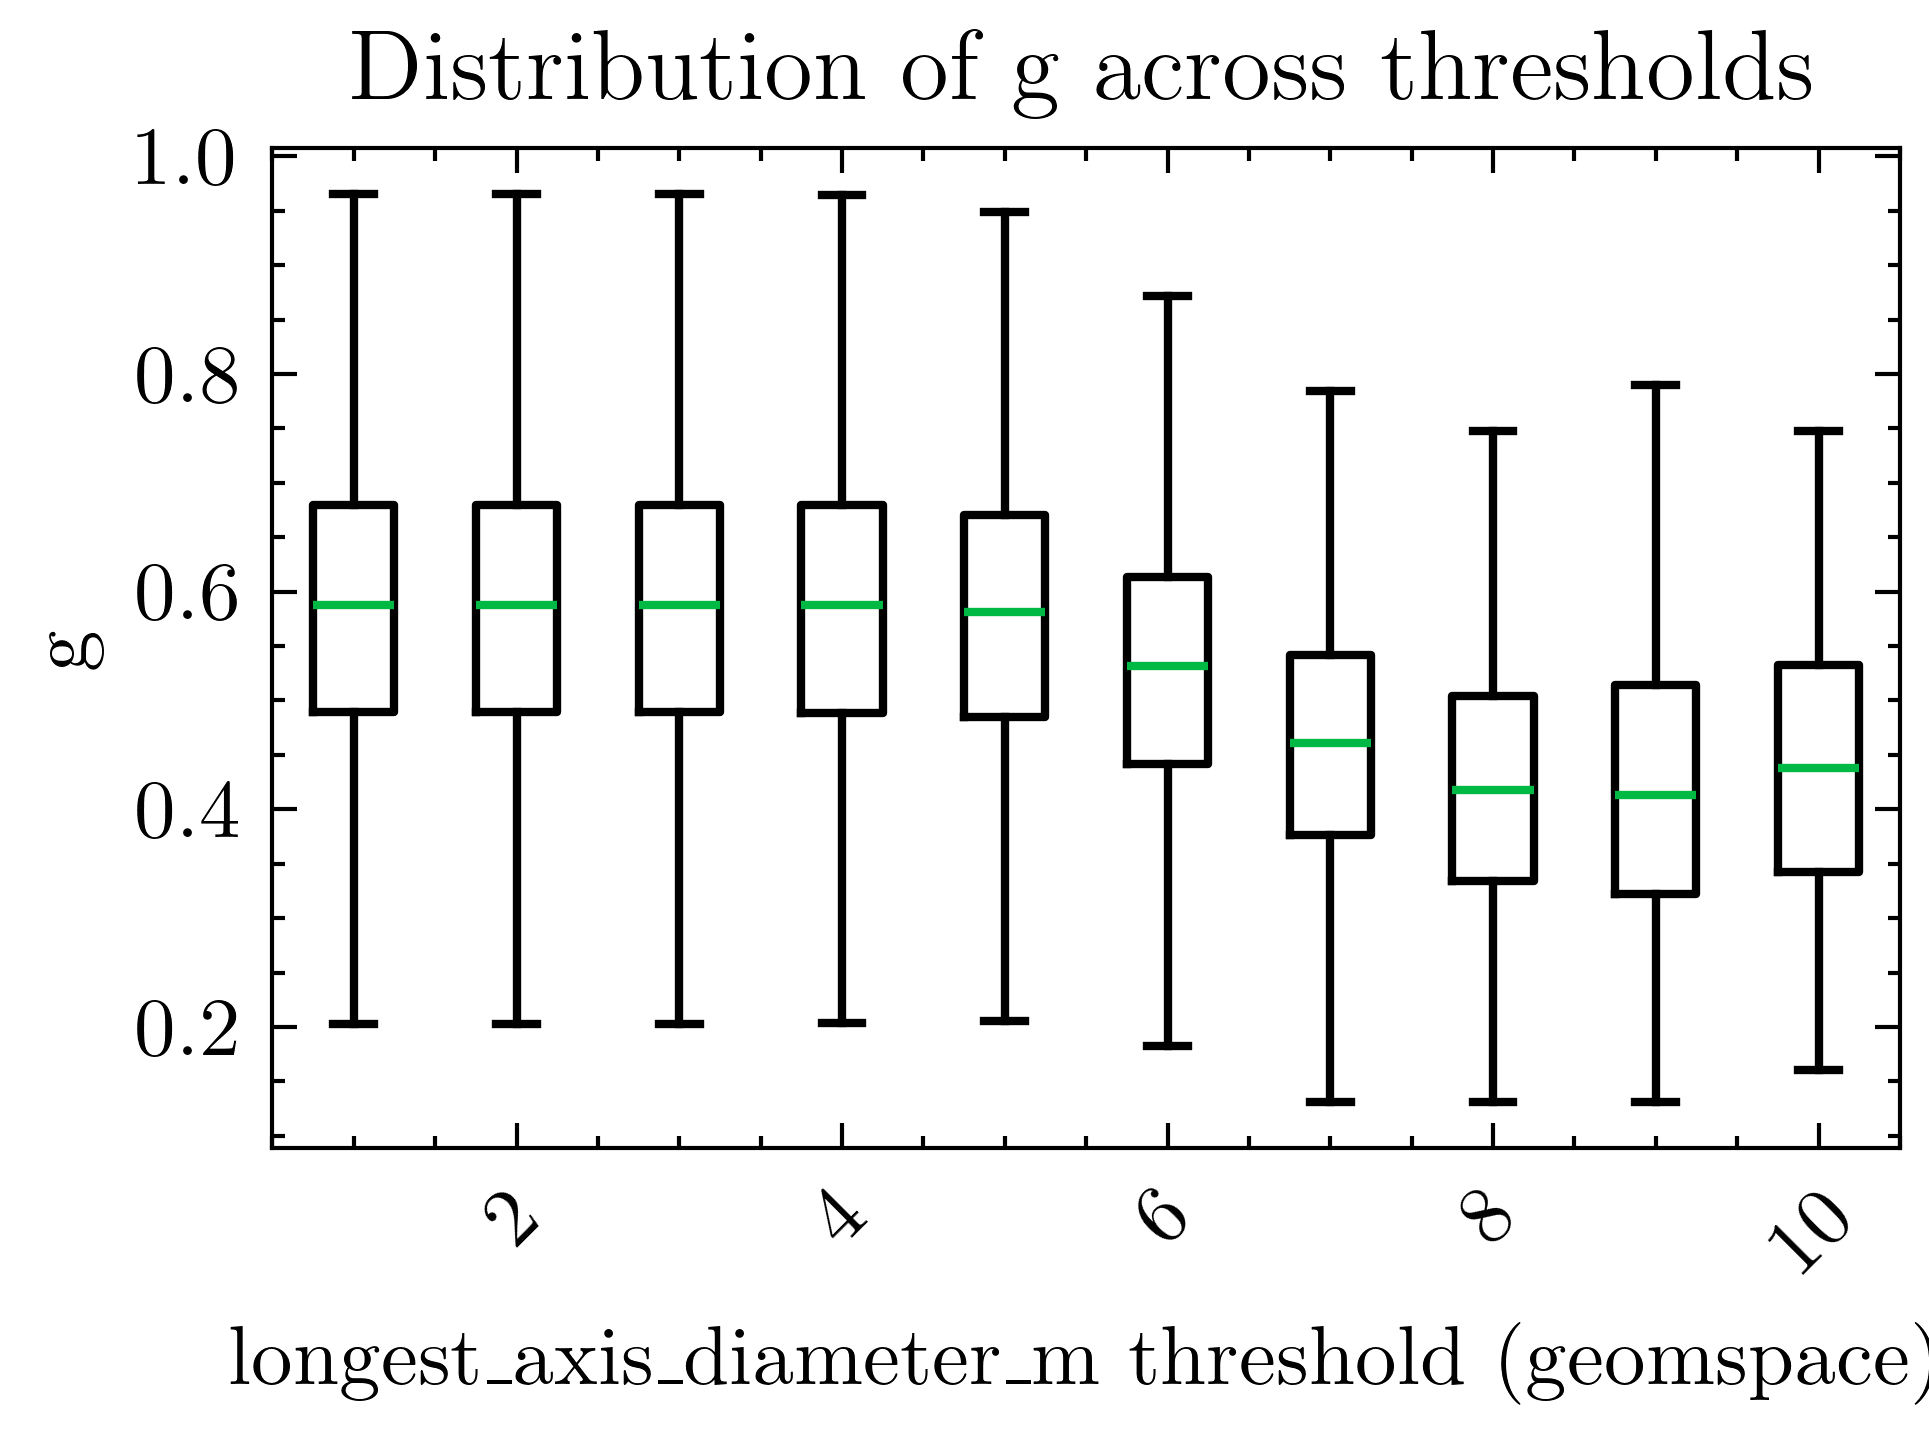

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

thresholds = np.geomspace(0.01, 10, 10)

all_data = []

for t in thresholds:
    gs = gamma_df.filter(
        (pl.col("g") < 2) &
        (pl.col("longest_axis_diameter_m") > t)
    )["g"].to_numpy()

    all_data.append(gs)

# boxplot
plt.boxplot(
    all_data,
    labels=[f"{t:.2g}" for t in thresholds],
    showfliers=False,
    whis=1.5  # default, controls whisker length
)
plt.xscale("linear")
plt.xticks(rotation=45)
plt.xlabel("longest_axis_diameter_m threshold (geomspace)")
plt.ylabel("g")
plt.title("Distribution of g across thresholds")
plt.show()